<a href="https://colab.research.google.com/github/AlvinManoj05/Data-Preprocessing-Project/blob/main/Data_Processing_Group_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [12]:
df=pd.read_csv("/content/drive/MyDrive/AI_ML/Datasets/istanbul_sales_data.csv")
# Change the location of dataset accordingly

## 3.Data Understanding

In [14]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I100001,C313884,Female,28.0,Clothing,2.0,600.16,Credit Card,2023-05-18,Istinye Park
1,I100002,C311565,Male,22.0,Technology,1.0,2100.00,Credit Card,2024-02-12,Zorlu Center
2,I100003,C366599,Male,20.0,Clothing,1.0,300.08,Cash,2023-09-11,Metrocity
3,I100004,C388172,Female,66.0,Books,5.0,75.75,Credit Card,2024-01-28,Metropol AVM
4,I100005,C389076,Female,53.0,Cosmetics,4.0,162.64,Cash,2023-10-24,Cevahir AVM


In [15]:
df.tail()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
499,I100500,C359469,Female,54.0,Clothing,2.0,600.16,Credit Card,2024-05-07,Istinye Park
500,I100501,C349248,Male,27.0,Souvenir,2.0,41.90,Credit Card,2023-04-18,Cevahir AVM
501,I100502,C319823,Female,41.0,Cosmetics,3.0,121.98,Debit Card,2024-10-13,Kanyon
502,I100503,C359037,Male,69.0,Food & Beverage,1.0,5.23,Cash,2023-09-29,Metropol AVM
503,```,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Shape
df.shape

(504, 10)

In [17]:
# Column names
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

In [18]:
# Data types
df.dtypes

,0
invoice_no,object
customer_id,object
gender,object
age,float64
category,object
quantity,float64
price,float64
payment_method,object
invoice_date,object
shopping_mall,object


In [19]:
#Complete information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      504 non-null    object 
 1   customer_id     503 non-null    object 
 2   gender          503 non-null    object 
 3   age             503 non-null    float64
 4   category        503 non-null    object 
 5   quantity        503 non-null    float64
 6   price           503 non-null    float64
 7   payment_method  503 non-null    object 
 8   invoice_date    503 non-null    object 
 9   shopping_mall   503 non-null    object 
dtypes: float64(3), object(7)
memory usage: 39.5+ KB


In [20]:
# Basic statistics
df.describe()

,age,quantity,price
count,503.000000,503.000000,503.000000
mean,40.862823,2.697813,1206.421948
std,13.424982,1.321043,3064.507191
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,41.900000
50%,39.000000,2.000000,143.360000
75%,51.000000,4.000000,900.240000
max,72.000000,5.000000,26250.000000


In [21]:
#Numerical columns
df.select_dtypes(include="number").columns

Index(['age', 'quantity', 'price'], dtype='object')

In [22]:
#Categorical columns
df.select_dtypes(include="object").columns

Index(['invoice_no', 'customer_id', 'gender', 'category', 'payment_method',
       'invoice_date', 'shopping_mall'],
      dtype='object')

# **Detect and Handle Missing values**

In [23]:
df.isnull().sum()/len(df)*100

,0
invoice_no,0.000000
customer_id,0.198413
gender,0.198413
age,0.198413
category,0.198413
quantity,0.198413
price,0.198413
payment_method,0.198413
invoice_date,0.198413
shopping_mall,0.198413


In [24]:
#handling missing values for numerical columns
numerical_columns=df.select_dtypes(include='number').columns
for column in numerical_columns:
  df[column]=df[column].fillna(df[column].median())

In [25]:
#handling missing values for categorical columns
categorical_columns=df.select_dtypes(include='object').columns
for column in categorical_columns:
  df[column]=df[column].fillna(df[column].mode()[0])


In [26]:
#checking
df.isnull().sum()

,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


#  Encoding

In [27]:
lb=LabelEncoder()

# Label encoding
df['gender']=lb.fit_transform(df['gender'])

columns_for_encoding=["category","payment_method","shopping_mall"]

# Onehot Encoding
df = pd.get_dummies(df,columns=columns_for_encoding,dtype=int)
df.head()

,invoice_no,customer_id,gender,age,quantity,price,invoice_date,category_Books,category_Clothing,category_Cosmetics,...,payment_method_Debit Card,shopping_mall_Akasya,shopping_mall_Cevahir AVM,shopping_mall_Emaar Square Mall,shopping_mall_Forum Istanbul,shopping_mall_Istinye Park,shopping_mall_Kanyon,shopping_mall_Metrocity,shopping_mall_Metropol AVM,shopping_mall_Zorlu Center
0,I100001,C313884,0,28.0,2.0,600.16,2023-05-18,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,I100002,C311565,1,22.0,1.0,2100.00,2024-02-12,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,I100003,C366599,1,20.0,1.0,300.08,2023-09-11,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,I100004,C388172,0,66.0,5.0,75.75,2024-01-28,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,I100005,C389076,0,53.0,4.0,162.64,2023-10-24,0,0,1,...,0,0,1,0,0,0,0,0,0,0


**Feature Extraction**

In [28]:
df['invoice_date']=pd.to_datetime(df['invoice_date'])
df['year']=df['invoice_date'].dt.year.astype(int)
df['month']=df['invoice_date'].dt.month.astype(int)
df['day']=df['invoice_date'].dt.day.astype(int)

df[['invoice_date','year','month','day']].head()

,invoice_date,year,month,day
0,2023-05-18,2023,5,18
1,2024-02-12,2024,2,12
2,2023-09-11,2023,9,11
3,2024-01-28,2024,1,28
4,2023-10-24,2023,10,24


# Feature Selection

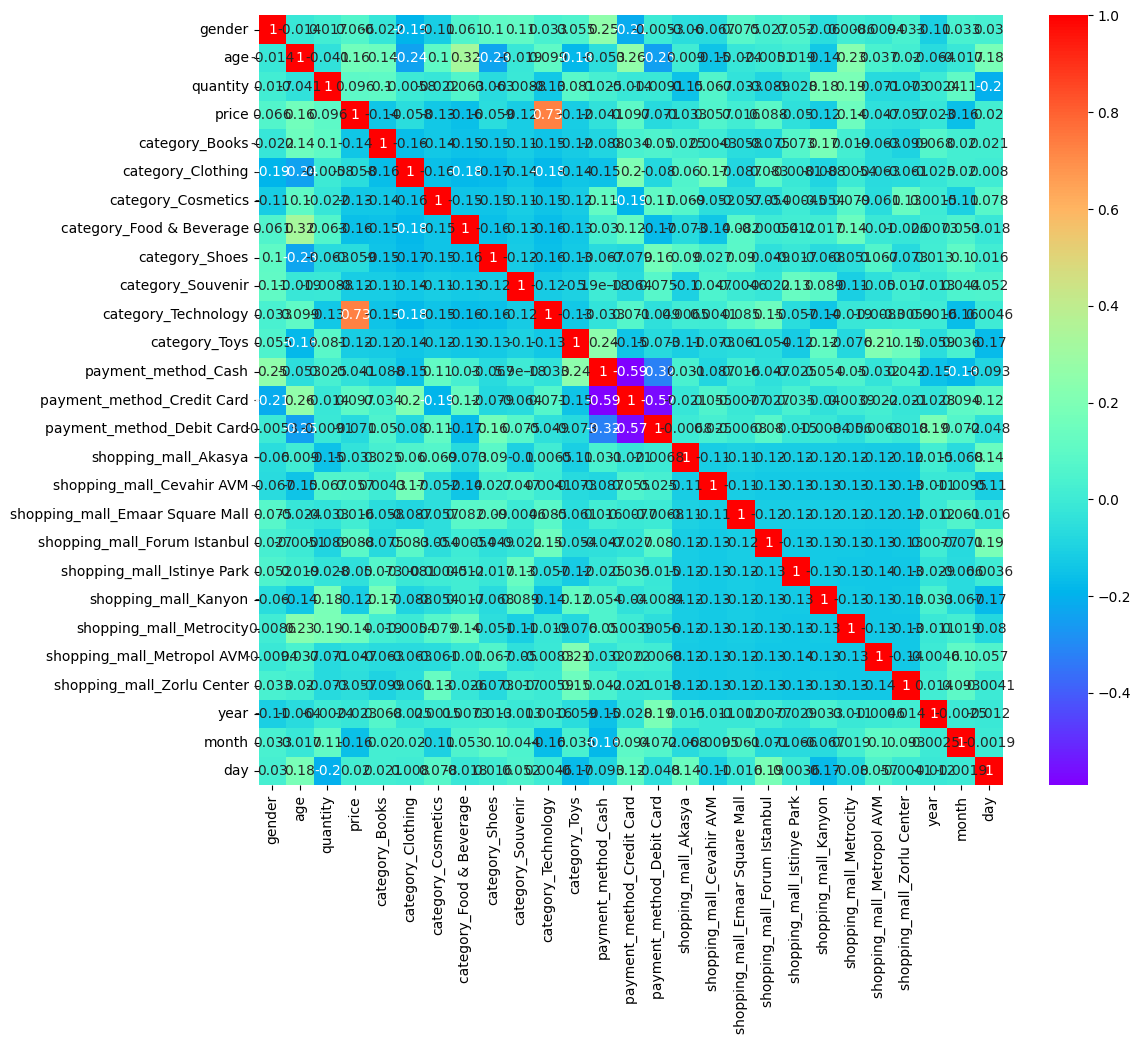

In [29]:
corr_result = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(
    data=corr_result,
    cmap="rainbow",
    annot=True
)
plt.show()



In [30]:
columns_to_reject = [
    "invoice_no",
    "customer_id",
    "gender",
    "age",
    "quantity",
    "invoice_date",
    "payment_method_Cash",
    "payment_method_Credit Card",
    "payment_method_Debit Card",
    "shopping_mall_Akasya",
    "shopping_mall_Cevahir AVM",
    "shopping_mall_Emaar Square Mall",
    "shopping_mall_Forum Istanbul",
    "shopping_mall_Istinye Park",
    "shopping_mall_Kanyon",
    "shopping_mall_Metrocity",
    "shopping_mall_Metropol AVM",
    "shopping_mall_Zorlu Center"
]

df.drop(columns=columns_to_reject, inplace=True)

In [31]:
X = df.drop(columns=["price"])
y = df["price"]

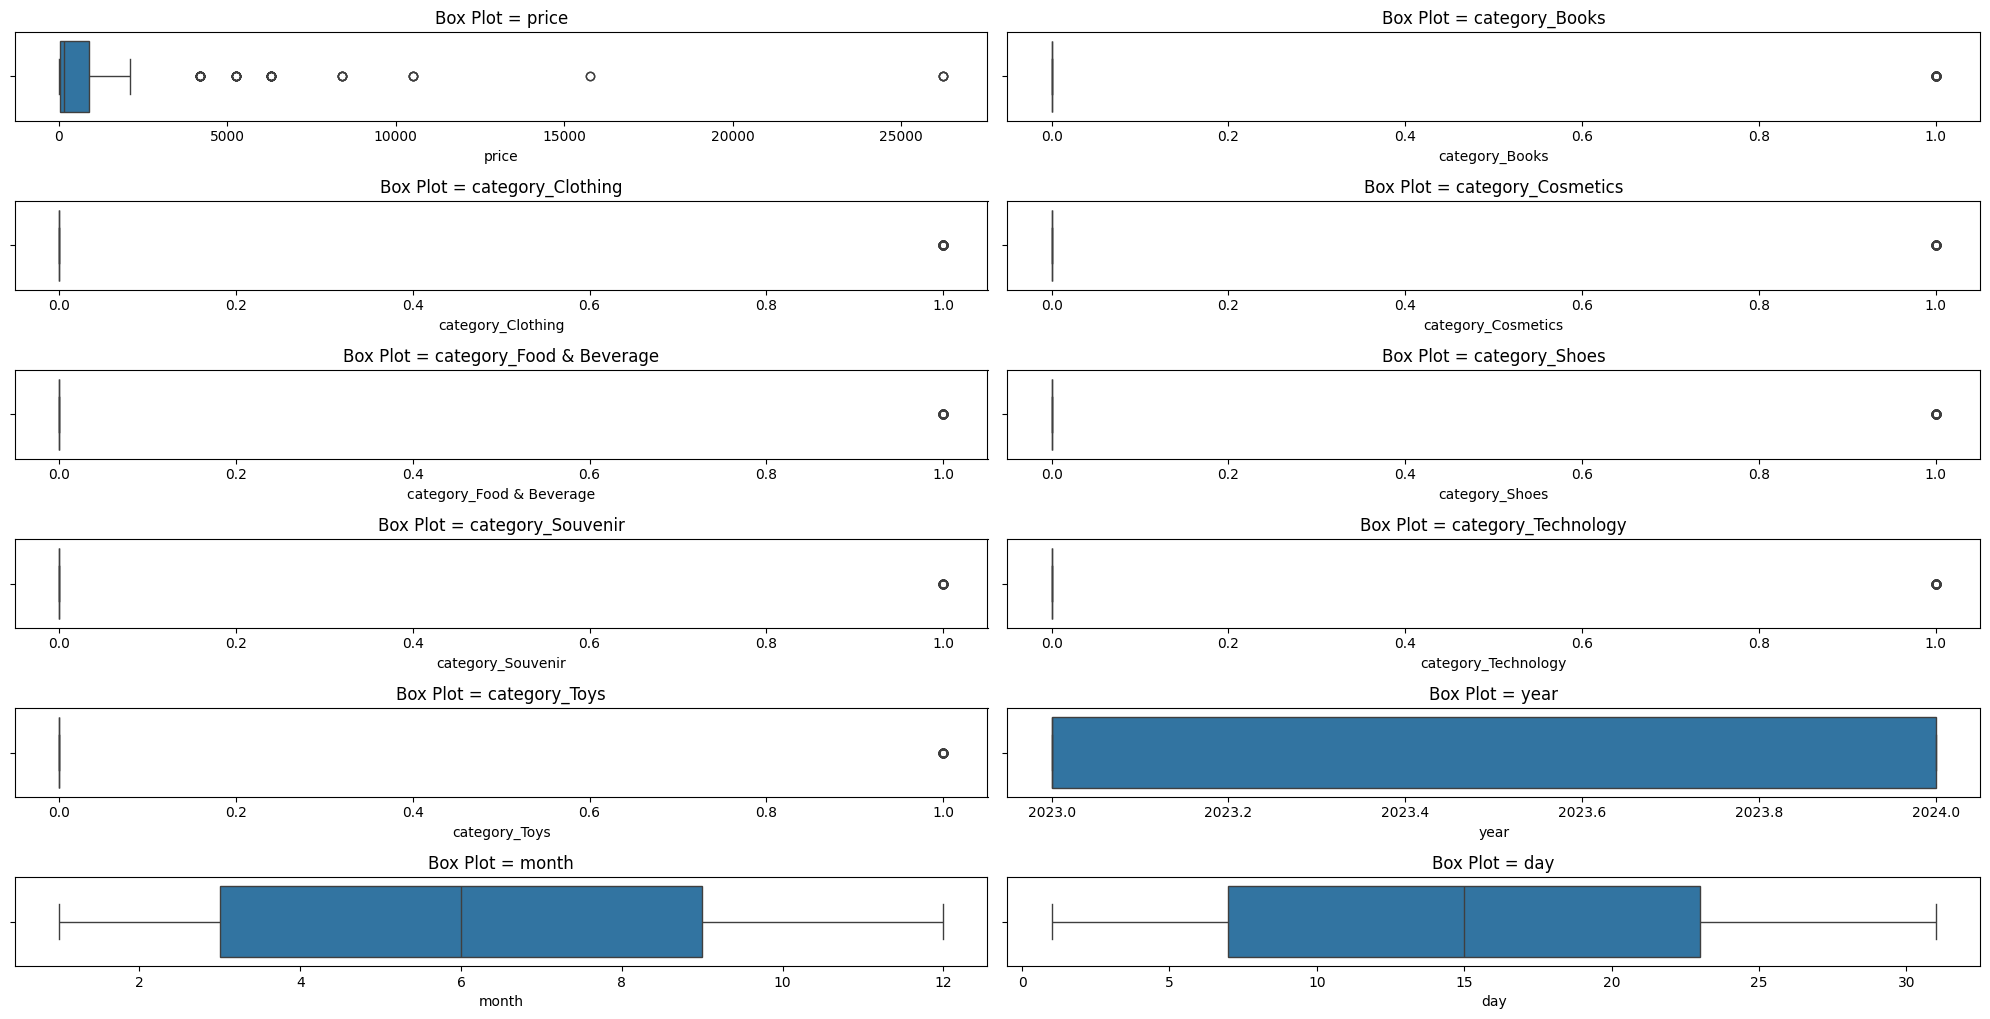

In [32]:

 columns = df.columns
plt.figure(figsize=(20,20))

for i ,col in enumerate(columns):
  plt.subplot(len(columns), 2,i+1)
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot = {col}")

plt.tight_layout()
plt.show()

In [33]:
columns_having_outliers = ["price"]

def handle_outliers(col):
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)


  IQR=Q3-Q1

  upper_bound = Q3 + 1.5 * IQR
  lower_bound = Q1 - 1.5 * IQR

  df[col] = df[col].clip(upper = upper_bound,lower=lower_bound)
  return

for col in columns_having_outliers:
  handle_outliers(col)

In [34]:
df.describe()

,price,category_Books,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,category_Toys,year,month,day
count,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000
mean,566.668353,0.121032,0.160714,0.119048,0.140873,0.134921,0.087302,0.138889,0.097222,2023.498016,6.359127,15.099206
std,749.769656,0.326488,0.367632,0.324166,0.348236,0.341978,0.282557,0.346174,0.296554,0.500493,3.407977,8.801437
min,5.230000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,1.000000,1.000000
25%,41.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,3.000000,7.000000
50%,143.360000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,6.000000,15.000000
75%,900.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024.000000,9.000000,23.000000
max,2187.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2024.000000,12.000000,31.000000
